Feature Selection Using Particle Swarm Optimization (PSO) on the Breast Cancer Dataset

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier


**loading dataset**

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [3]:
df = X.copy()
df["target"] = y


df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Exploratory Data Analysis

Dataset Overview

In [5]:
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nFeature Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

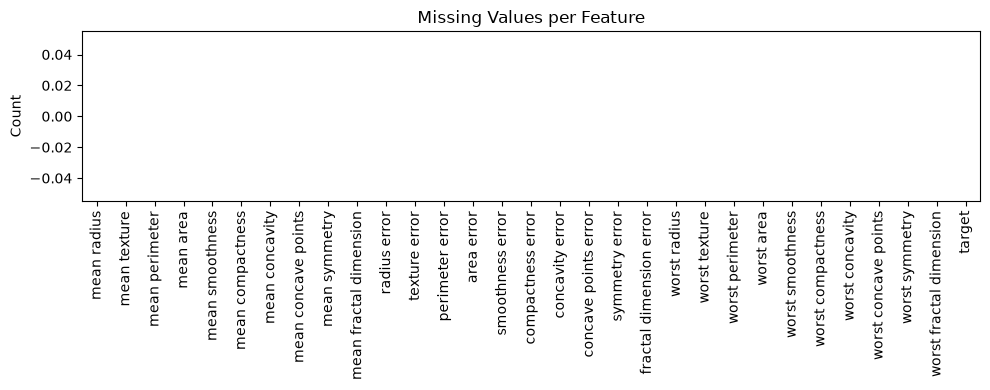

In [8]:
import matplotlib.pyplot as plt
missing = df.isnull().sum()

plt.figure(figsize=(10,4))
missing.plot(kind="bar")
plt.title("Missing Values per Feature")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("missing_values.png", dpi=300)

plt.show()

Class Distribution

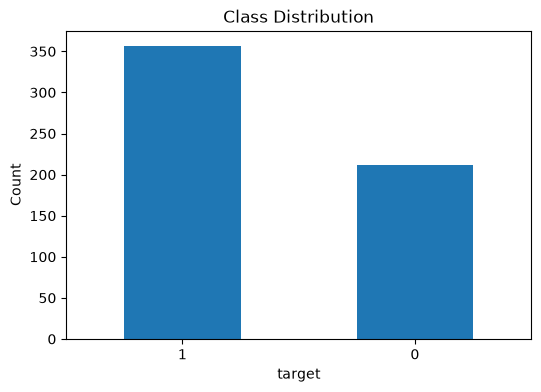

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['target'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

plt.savefig("class_distribution.png", dpi=300, bbox_inches='tight')


Target Distribution Pie Chart

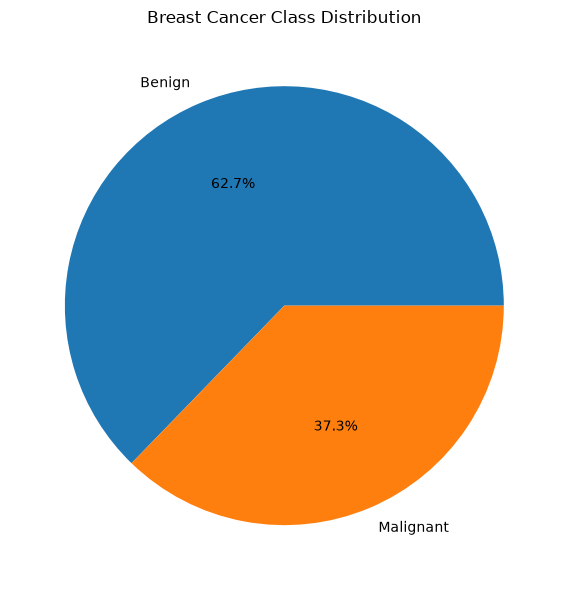

In [9]:
plt.figure(figsize=(6,6))

df["target"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Benign","Malignant"]
)

plt.ylabel("")
plt.title("Breast Cancer Class Distribution")

plt.tight_layout()

plt.savefig("class_distribution_pie.png",dpi=300)

plt.show()

Feature Statistics

In [11]:
display(df.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Histograms

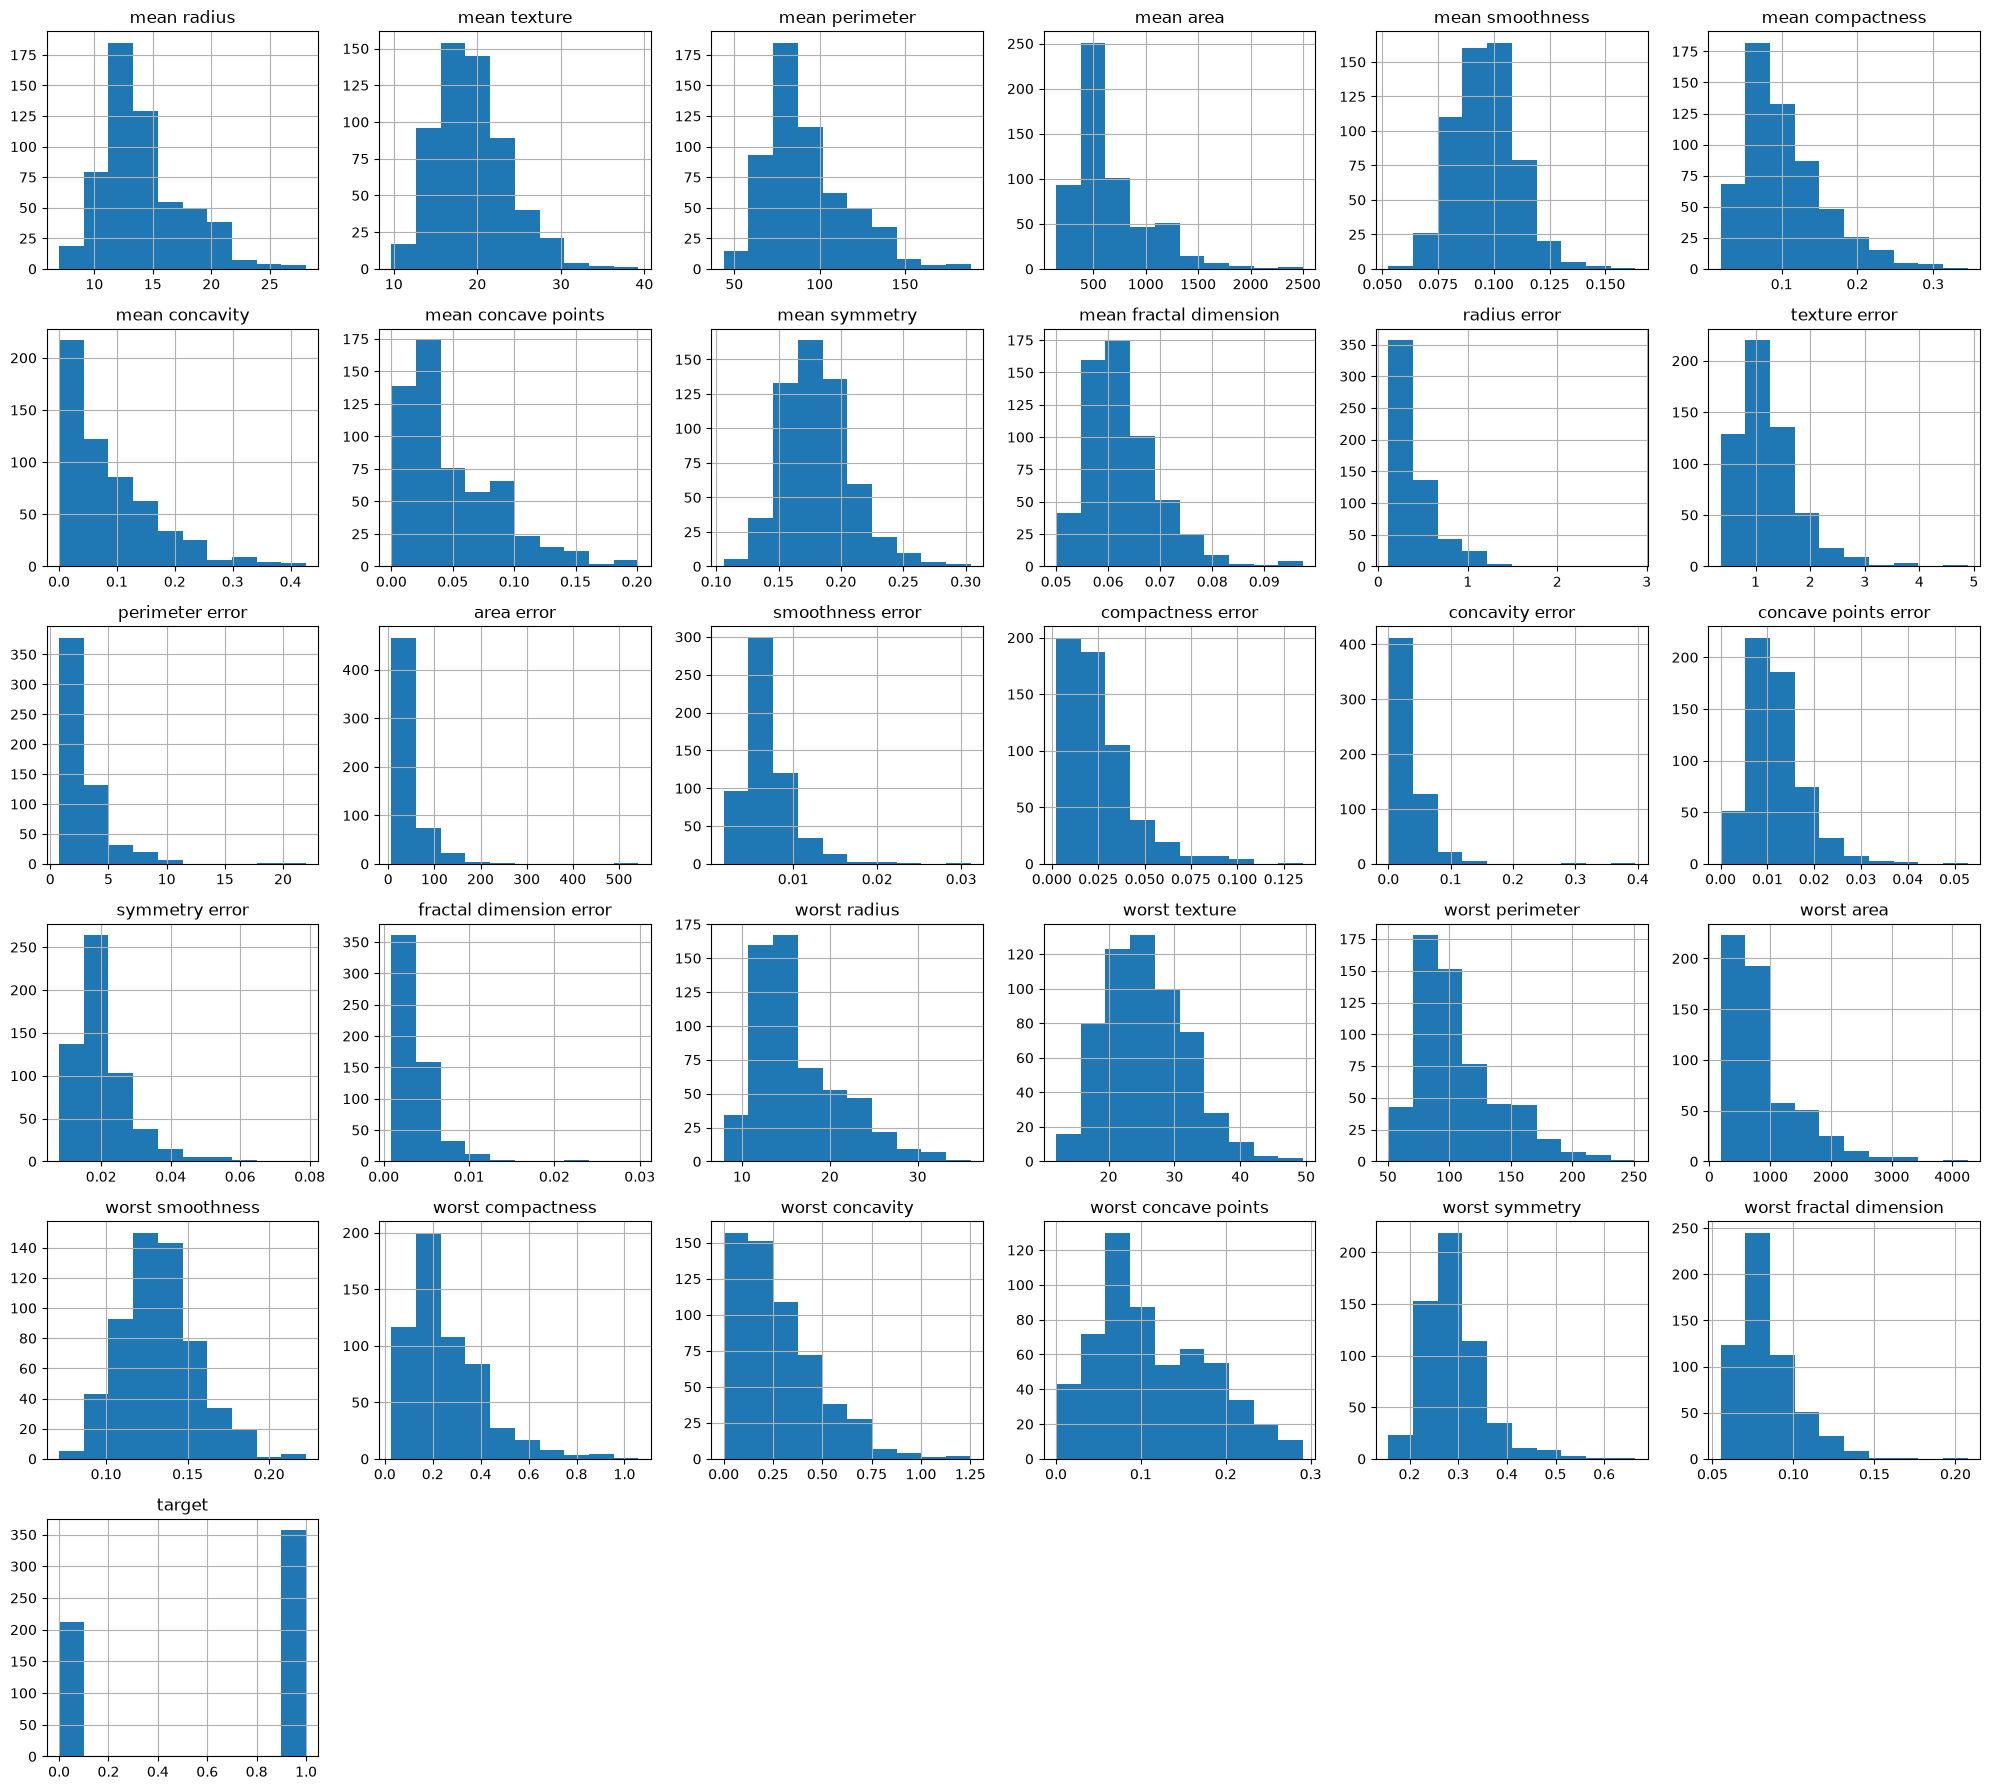

In [12]:
df.hist(figsize=(20,18))

plt.tight_layout()

plt.savefig("feature_histograms.png",dpi=300)

plt.show()

Correlation Matrix

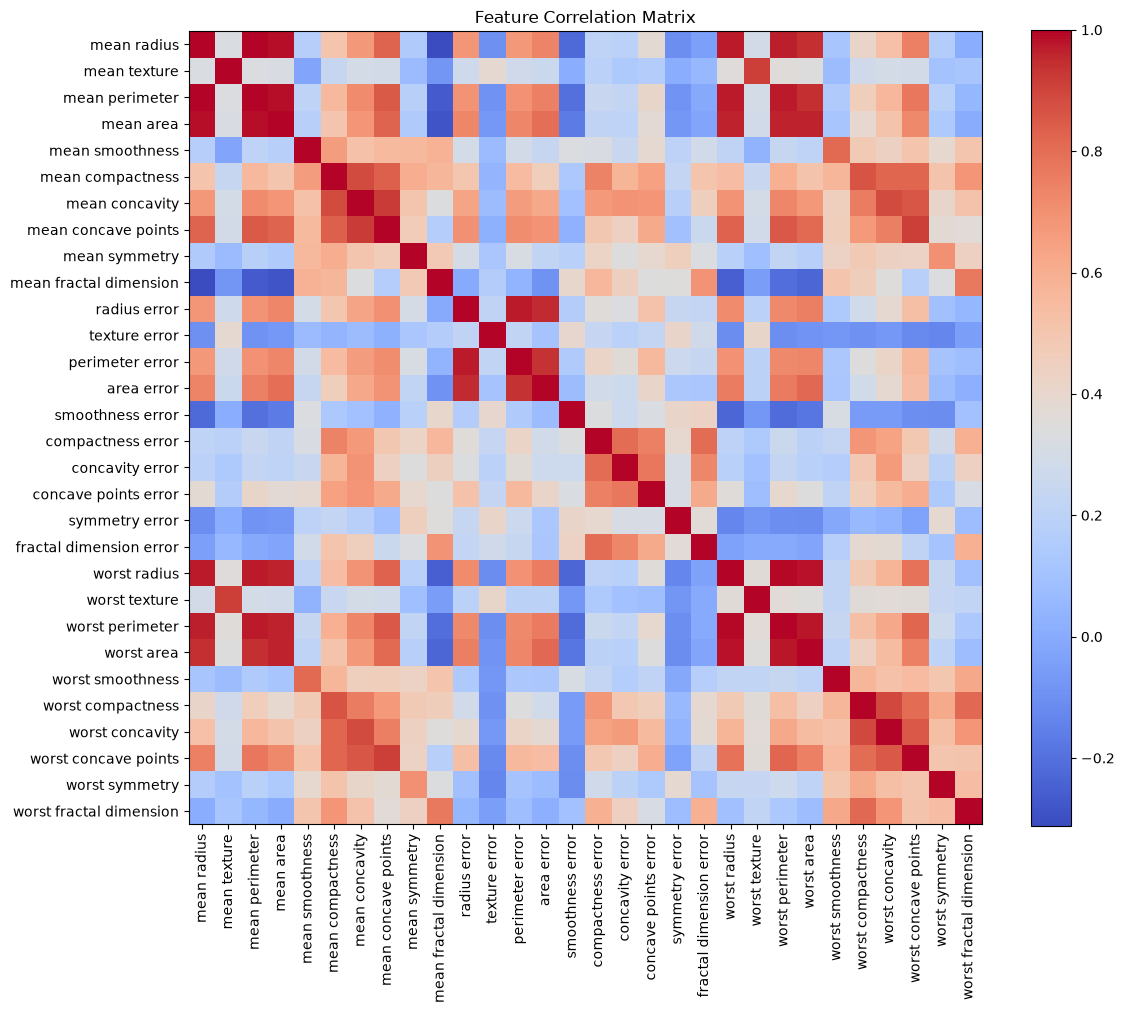

In [13]:
corr = df.drop("target",axis=1).corr()

plt.figure(figsize=(12,10))

plt.imshow(corr,cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)

plt.yticks(range(len(corr.columns)),corr.columns)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.savefig("correlation_matrix.png",dpi=300)

plt.show()

Top Correlated Features

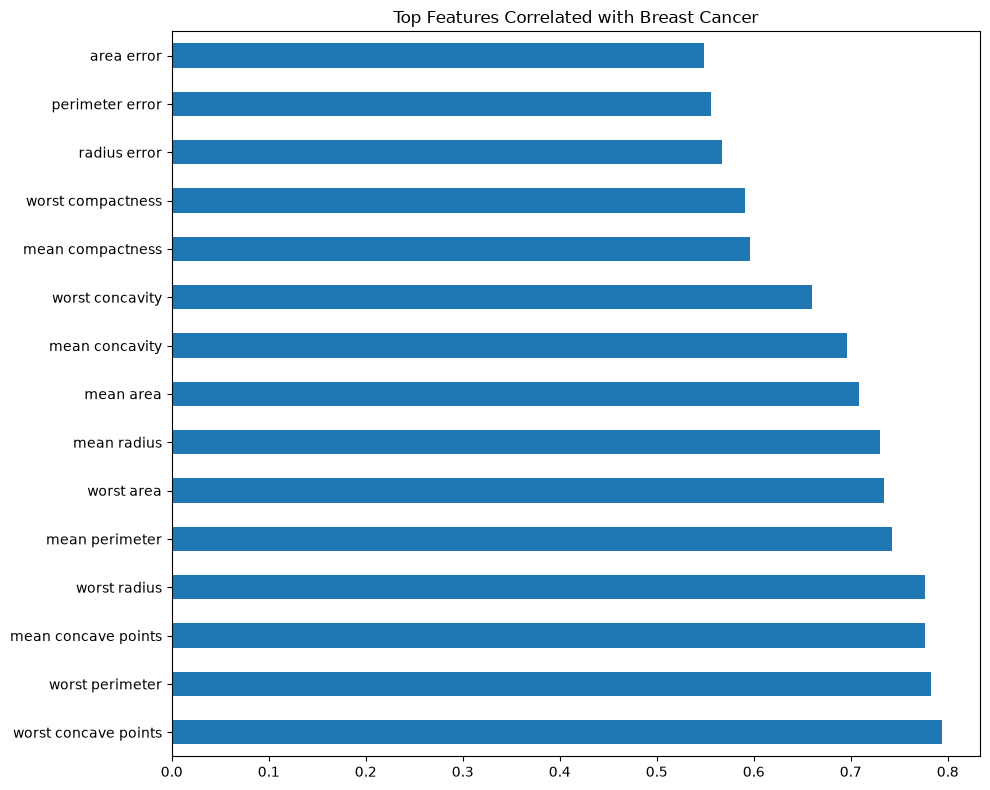

In [14]:
corr_target = (
    df.corr()["target"]
      .drop("target")
      .abs()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

corr_target.head(15).plot(kind="barh")

plt.title("Top Features Correlated with Breast Cancer")

plt.tight_layout()

plt.savefig("top_correlated_features.png",dpi=300)

plt.show()

Data Preprocessing

split

In [16]:
# Split into features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

In [17]:
# Split data into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [18]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [19]:
print("Data prepared successfully ")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Data prepared successfully 
Training data shape: (398, 30)
Testing data shape: (171, 30)


**Particle Swarm Optimization (PSO) for Feature Selection**

In [20]:
#installing PSO library
!pip install pyswarms

  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl (156 kB)

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [pyyaml]
   -------- ------------------------------- 1/5 [pyyaml]
   -------- ------------------------------- 1/5 [pyyaml]
   ---------------- ----------------------- 2/5 [future]
   ---------------- ----------------------- 2/5 [future]
   ---------------- ----------------------- 2/5 [future]
   ---------------- ----------------------- 2/5 [future]
   ---------------- ----------------------- 2/5 [future]
   ---------------- ----------------------- 2/5 [future]
   ----------------

In [21]:
import pyswarms as ps
import numpy as np

**Fitness Function.**

The Fitness function evaluates how good each subset of feature is based on the classifcation accuracy

In [22]:
# Objective function: minimize (1 - accuracy)
def fitness_function(particles):
    scores = []
    for particle in particles:
        # Convert continuous values to boolean mask (selected features)
        mask = particle > 0.5
        if np.sum(mask) == 0:  # if no features selected
            scores.append(1)
            continue

        # Train a model with selected features
        X_train_sel = X_train[:, mask]
        X_test_sel = X_test[:, mask]

        model = RandomForestClassifier(random_state=42)
        model.fit(X_train_sel, y_train)
        pred = model.predict(X_test_sel)
        acc = accuracy_score(y_test, pred)
        scores.append(1 - acc)  # minimize 1 - accuracy

    return np.array(scores)


**Initialize and run PSO**

In [23]:
# PSO parameters
options = {'c1': 2, 'c2': 2, 'w': 0.9}

# Initialize optimizer
optimizer = ps.single.GlobalBestPSO(
    n_particles=20,
    dimensions=X_train.shape[1],
    options=options
)

# Run optimization
cost, pos = optimizer.optimize(fitness_function, iters=20)

print("Best cost (1 - accuracy):", cost)


2026-08-02 16:46:09,779 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 2, 'c2': 2, 'w': 0.9}
pyswarms.single.global_best:   0%|          |0/20

pyswarms.single.global_best: 100%|██████████|20/20, best_cost=0.00585
2026-08-02 16:47:26,710 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.005847953216374324, best pos: [ 3.77976971e+00  5.04153001e-01  1.19003545e-01  2.10151750e+00
  1.56121468e+00 -2.34433904e+00  1.24815405e+00  3.78745207e-01
  1.47486814e+00 -2.69008956e+00  3.09108043e+00  4.25127590e+00
  1.44238786e-01 -4.37552249e-01  9.56758520e-03 -6.59814926e-01
  2.43316516e+00  9.86877068e-02 -1.94607883e-01  2.55395629e+00
  3.90375506e+00 -5.51297369e-01  5.69913762e-01 -3.91248318e+00
  8.99351324e-01 -5.56400602e-01 -7.72904777e+00 -6.10403299e-03
  8.06599410e-02  3.45254892e+00]


Best cost (1 - accuracy): 0.005847953216374324


**Selected Feature and Evaluation**

In [24]:
# Get the selected features from PSO result
selected_features = np.where(pos > 0.5)[0]
print("Selected feature indices:", selected_features)
print("Number of selected features:", len(selected_features))

# Evaluate performance using only selected features
X_train_sel = X_train[:, selected_features]
X_test_sel = X_test[:, selected_features]

model = RandomForestClassifier(random_state=42)
model.fit(X_train_sel, y_train)
pred = model.predict(X_test_sel)

acc = accuracy_score(y_test, pred)
print("Accuracy using selected features:", acc)



Selected feature indices: [ 0  1  3  4  6  8 10 11 16 19 20 22 24 29]
Number of selected features: 14
Accuracy using selected features: 0.9941520467836257


In [25]:
# Accuracy with all features
model_full = RandomForestClassifier(random_state=42)
model_full.fit(X_train, y_train)
pred_full = model_full.predict(X_test)
acc_full = accuracy_score(y_test, pred_full)

print("Accuracy with all features:", acc_full)
print("Accuracy after PSO feature selection:", acc)

Accuracy with all features: 0.9707602339181286
Accuracy after PSO feature selection: 0.9941520467836257


After applying Particle Swarm Optimization (PSO) for feature selection, the model’s accuracy improved from **97.07%** (using all features) to **99.41%** (using only the selected features).
This indicates that PSO effectively eliminated redundant or less important features, allowing the classifier to perform better with fewer inputs.
The improvement demonstrates that PSO can enhance both accuracy and efficiency by focusing on the most relevant attributes of the Breast Cancer dataset.

In [26]:
# PSO feature selection - robust version
import numpy as np
import pyswarms as ps
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Ensure X_train/X_test are numpy arrays (works if they are pandas DataFrames too)
X_train_np = np.asarray(X_train)
X_test_np  = np.asarray(X_test)
y_train_np = np.asarray(y_train)
y_test_np  = np.asarray(y_test)

n_features = X_train_np.shape[1]

def fitness_function(particles):
    """
    particles: array shape (n_particles, dimensions)
    returns: array shape (n_particles,) with costs (to minimize)
    """
    n_particles = particles.shape[0]
    scores = np.zeros(n_particles)

    for i, particle in enumerate(particles):
        mask = particle > 0.5  # boolean mask, length = n_features
        if mask.sum() == 0:
            # If no features selected, give a very bad score
            scores[i] = 1.0
            continue

        # Subset data using mask (works with numpy arrays)
        Xtr = X_train_np[:, mask]
        Xte = X_test_np[:, mask]

        # Train and evaluate
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(Xtr, y_train_np)
        preds = model.predict(Xte)
        acc = accuracy_score(y_test_np, preds)

        scores[i] = 1.0 - acc  # minimize (1 - accuracy)

    return scores

# PSO options
options = {'c1': 1.5, 'c2': 1.5, 'w': 0.7}

# Initialize optimizer: dimensions = n_features
optimizer = ps.single.GlobalBestPSO(
    n_particles=30,
    dimensions=n_features,
    options=options
)

# Run optimization (iters small for demo; increase for better search)
cost, pos = optimizer.optimize(fitness_function, iters=30, verbose=True)

# Convert pos -> binary mask and selected feature indices
mask = pos > 0.5
selected_features = np.where(mask)[0]

print("Best cost (1 - accuracy):", cost)
print("Selected feature indices:", selected_features)
print("Number selected:", mask.sum())

# Evaluate final model using selected features (handle case of zero selected features)
if mask.sum() == 0:
    print("No features selected by PSO — consider increasing iterations or changing options.")
else:
    Xtr_sel = X_train_np[:, mask]
    Xte_sel = X_test_np[:, mask]
    model_sel = RandomForestClassifier(n_estimators=200, random_state=42)
    model_sel.fit(Xtr_sel, y_train_np)
    preds_sel = model_sel.predict(Xte_sel)
    acc_sel = accuracy_score(y_test_np, preds_sel)
    print("Accuracy using PSO-selected features:", acc_sel)

    # Also compute full-model baseline if needed
    model_full = RandomForestClassifier(n_estimators=200, random_state=42)
    model_full.fit(X_train_np, y_train_np)
    preds_full = model_full.predict(X_test_np)
    acc_full = accuracy_score(y_test_np, preds_full)
    print("Accuracy with all features:", acc_full)


2026-08-02 16:48:28,533 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.00585
2026-08-02 16:51:29,065 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.005847953216374324, best pos: [0.03622165 0.64211334 0.45911798 0.07404367 0.30208321 0.5022338
 0.4756103  0.32208659 0.32903706 0.52349712 0.31724216 0.88854373
 0.26204055 0.41057537 0.70017914 0.88236726 0.92344464 0.54624891
 0.63491575 0.22727833 0.303998   0.40202344 0.69268935 0.52434381
 0.54970682 0.90655108 0.6475812  0.02075858 0.51918653 0.28717715]


Best cost (1 - accuracy): 0.005847953216374324
Selected feature indices: [ 1  5  9 11 14 15 16 17 18 22 23 24 25 26 28]
Number selected: 15
Accuracy using PSO-selected features: 0.9883040935672515
Accuracy with all features: 0.9707602339181286


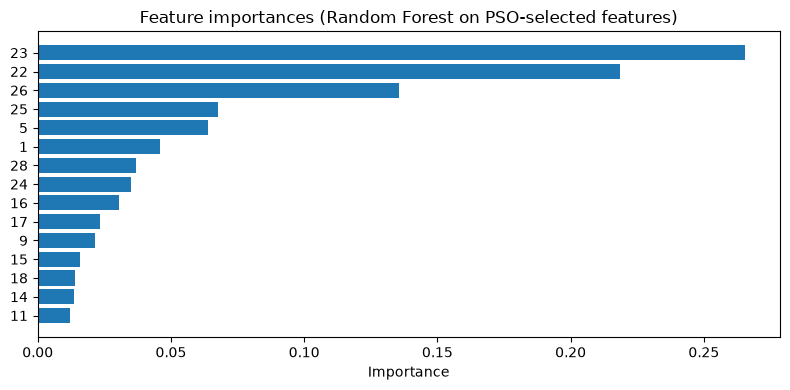

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Choose which model/features to show:
# For full model:
feat_names = np.asarray(X_train.columns) if hasattr(X_train, "columns") else np.arange(X_train_np.shape[1])
imp_model = model_full.feature_importances_ if 'model_full' in globals() else None

# For selected model: map selected importances to original feature names
if 'model_sel' in globals():
    imp_sel = model_sel.feature_importances_
    # If using selected indices, match them to original names
    feat_sel_names = feat_names[selected_features] if feat_names is not None else selected_features
    sorted_idx = np.argsort(imp_sel)
    plt.figure(figsize=(8, max(4, 0.25*len(feat_sel_names))))
    plt.barh(np.arange(len(imp_sel)), imp_sel[sorted_idx])
    plt.yticks(np.arange(len(imp_sel)), feat_sel_names[sorted_idx])
    plt.xlabel("Importance")
    plt.title("Feature importances (Random Forest on PSO-selected features)")
    plt.savefig("feature_importance.png",dpi=300)

    plt.tight_layout()
    plt.show()
elif imp_model is not None:
    sorted_idx = np.argsort(imp_model)
    plt.figure(figsize=(8, max(4, 0.25*len(feat_names))))
    plt.barh(np.arange(len(imp_model)), imp_model[sorted_idx])
    plt.yticks(np.arange(len(imp_model)), feat_names[sorted_idx])
    plt.xlabel("Importance")
    plt.title("Feature importances (Random Forest on all features)")
    plt.tight_layout()
    plt.show()
else:
    print("No trained model found (model_sel or model_full).")




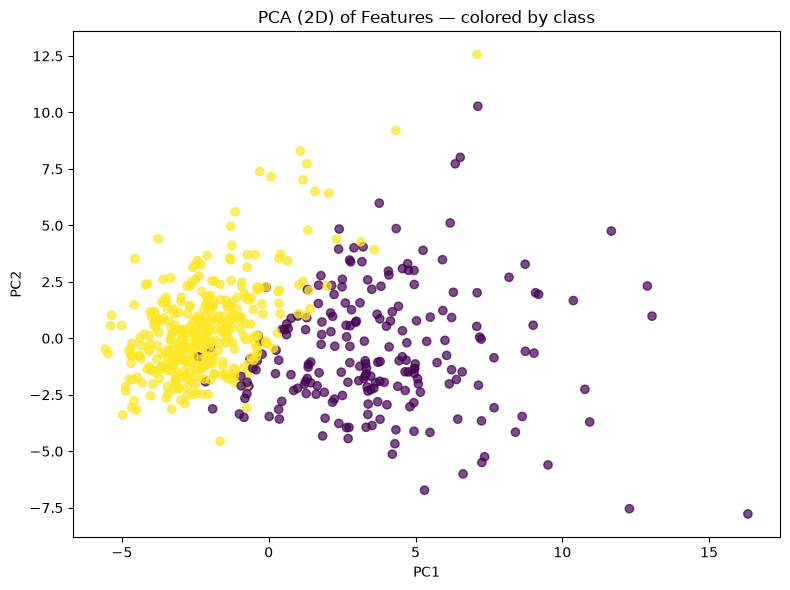

<Figure size 640x480 with 0 Axes>

In [28]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

X_all_np = np.asarray(X)  # original features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all_np)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

y_np = np.asarray(y)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_np, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) of Features — colored by class")
plt.tight_layout()
plt.show()

plt.savefig("pca_projection.png", dpi=300, bbox_inches='tight')

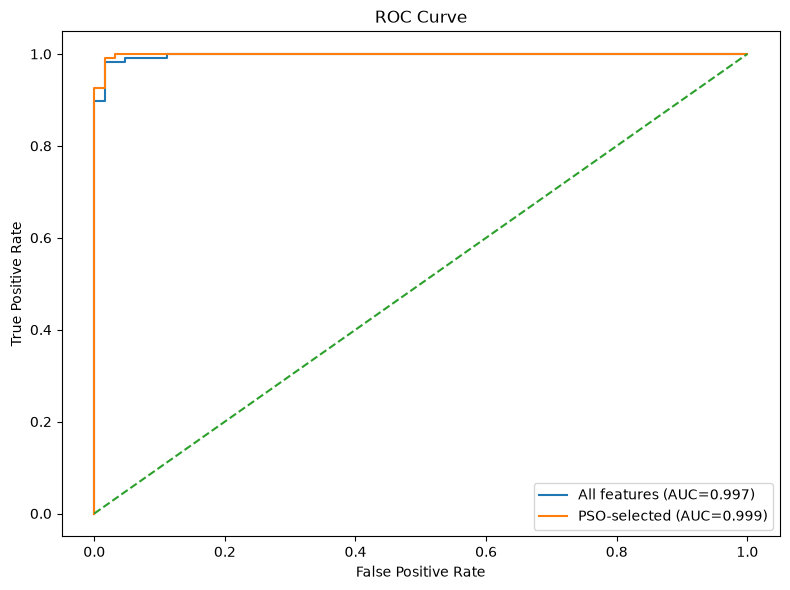

In [29]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Ensure probability arrays exist
if 'model_full' in globals():
    Xte_full = np.asarray(X_test)
    prob_full = model_full.predict_proba(Xte_full)[:,1]
else:
    prob_full = None

if 'model_sel' in globals() and mask.sum() > 0:
    Xte_sel = np.asarray(X_test)[:, mask]
    prob_sel = model_sel.predict_proba(Xte_sel)[:,1]
else:
    prob_sel = None

y_np = np.asarray(y_test)

plt.figure(figsize=(8,6))
if prob_full is not None:
    fpr_f, tpr_f, _ = roc_curve(y_np, prob_full)
    auc_f = auc(fpr_f, tpr_f)
    plt.plot(fpr_f, tpr_f, label=f"All features (AUC={auc_f:.3f})")
if prob_sel is not None:
    fpr_s, tpr_s, _ = roc_curve(y_np, prob_sel)
    auc_s = auc(fpr_s, tpr_s)
    plt.plot(fpr_s, tpr_s, label=f"PSO-selected (AUC={auc_s:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.savefig("roc_curve.png",dpi=300)

plt.tight_layout()
plt.show()




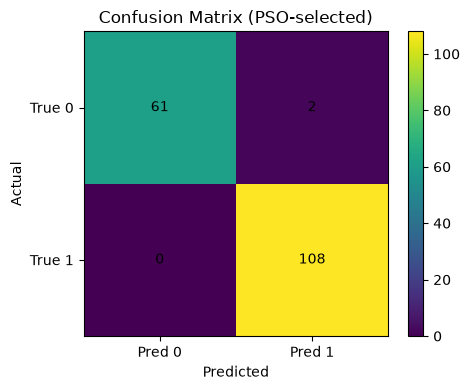

<Figure size 640x480 with 0 Axes>

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

if 'model_sel' in globals() and mask.sum() > 0:
    Xte_sel = np.asarray(X_test)[:, mask]
    preds = model_sel.predict(Xte_sel)
    cm = confusion_matrix(np.asarray(y_test), preds)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.colorbar()
    plt.xticks([0,1], ["Pred 0","Pred 1"])
    plt.yticks([0,1], ["True 0","True 1"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center')
    plt.title("Confusion Matrix (PSO-selected)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    plt.savefig("confusion_matrix.png", dpi=300)
else:
    print("No PSO-selected model available to show confusion matrix.")


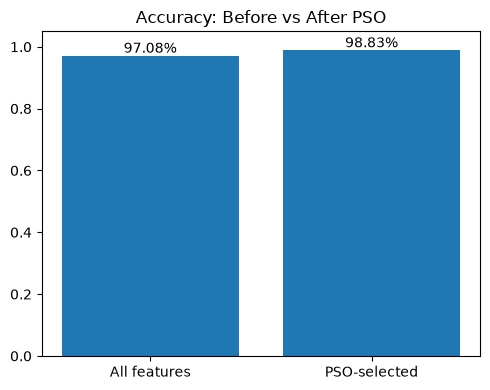

<Figure size 640x480 with 0 Axes>

In [31]:
import matplotlib.pyplot as plt

if 'acc_full' in globals() and 'acc_sel' in globals():
    labels = ["All features", "PSO-selected"]
    values = [acc_full, acc_sel]
    plt.figure(figsize=(5,4))
    plt.bar(labels, values)
    plt.ylim(0,1.05)
    for i,v in enumerate(values):
        plt.text(i, v+0.01, f"{v*100:.2f}%", ha='center')
    plt.title("Accuracy: Before vs After PSO")
    plt.tight_layout()
    plt.show()
    plt.savefig("accuracy_comparison.png", dpi=300)
else:
    print("Run evaluation to compute acc_full and acc_sel first.")

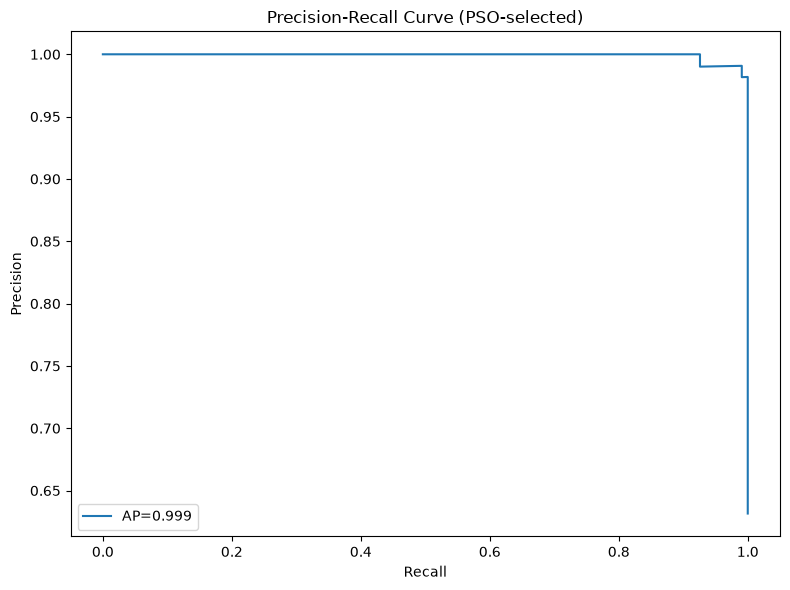

<Figure size 640x480 with 0 Axes>

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

if 'model_sel' in globals() and mask.sum() > 0:
    Xte_sel = np.asarray(X_test)[:, mask]
    prob_sel = model_sel.predict_proba(Xte_sel)[:,1]
    precision, recall, _ = precision_recall_curve(np.asarray(y_test), prob_sel)
    ap = average_precision_score(np.asarray(y_test), prob_sel)
    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, label=f"AP={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (PSO-selected)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig("precision_recall_curve.png", dpi=300)
else:
    print("PSO-selected model or probabilities not available.")




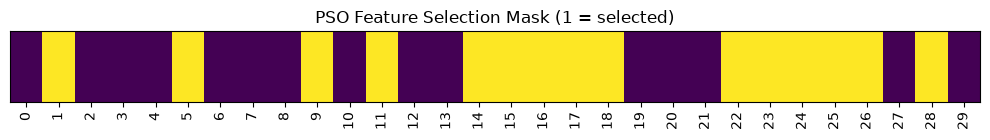

In [33]:
import matplotlib.pyplot as plt
import numpy as np

if 'mask' in globals():
    plt.figure(figsize=(10,1.5))
    plt.imshow(mask.reshape(1,-1), aspect='auto')
    plt.yticks([])
    labels = np.asarray(X_train.columns) if hasattr(X_train, "columns") else np.arange(len(mask))
    plt.xticks(np.arange(len(mask)), labels, rotation=90)
    plt.title("PSO Feature Selection Mask (1 = selected)")
    plt.tight_layout()
    plt.show()
else:
    print("Run PSO to obtain mask first.")


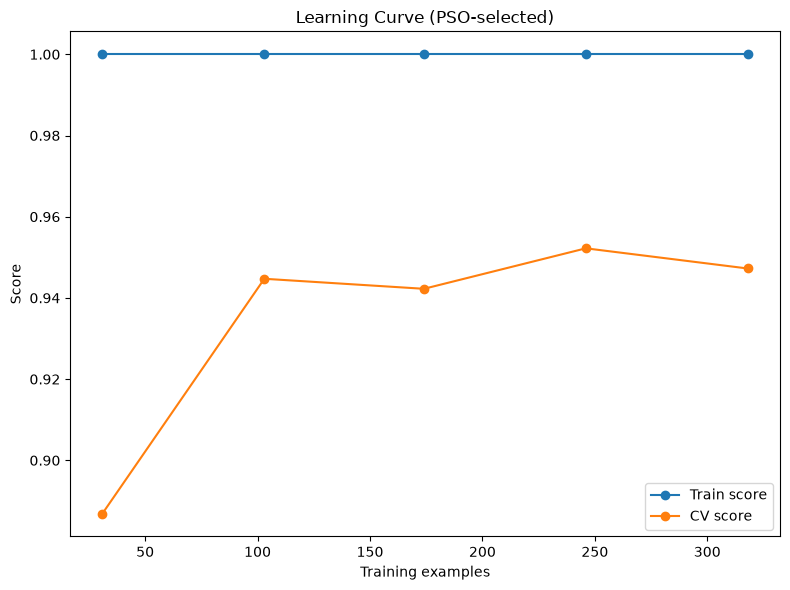

<Figure size 640x480 with 0 Axes>

In [34]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

if 'model_sel' in globals() and mask.sum() > 0:
    Xtr_sel = np.asarray(X_train)[:, mask]
    ytr = np.asarray(y_train)
    train_sizes, train_scores, test_scores = learning_curve(
        RandomForestClassifier(n_estimators=200, random_state=42),
        Xtr_sel, ytr, cv=5, train_sizes=np.linspace(0.1,1.0,5), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)
    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, marker='o', label='Train score')
    plt.plot(train_sizes, test_mean, marker='o', label='CV score')
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.title("Learning Curve (PSO-selected)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig("learning_curve.png", dpi=300)
else:
    print("Need PSO-selected features to plot learning curve.")



The learning curve demonstrates that the Random Forest classifier consistently achieves perfect performance on the training data while maintaining a stable cross-validation accuracy of approximately 95%. As the number of training samples increases, the validation score improves and converges toward a stable value, indicating good generalization capability. The small gap between the training and validation curves suggests only mild overfitting, which is expected for ensemble tree-based models and does not significantly affect predictive performance.

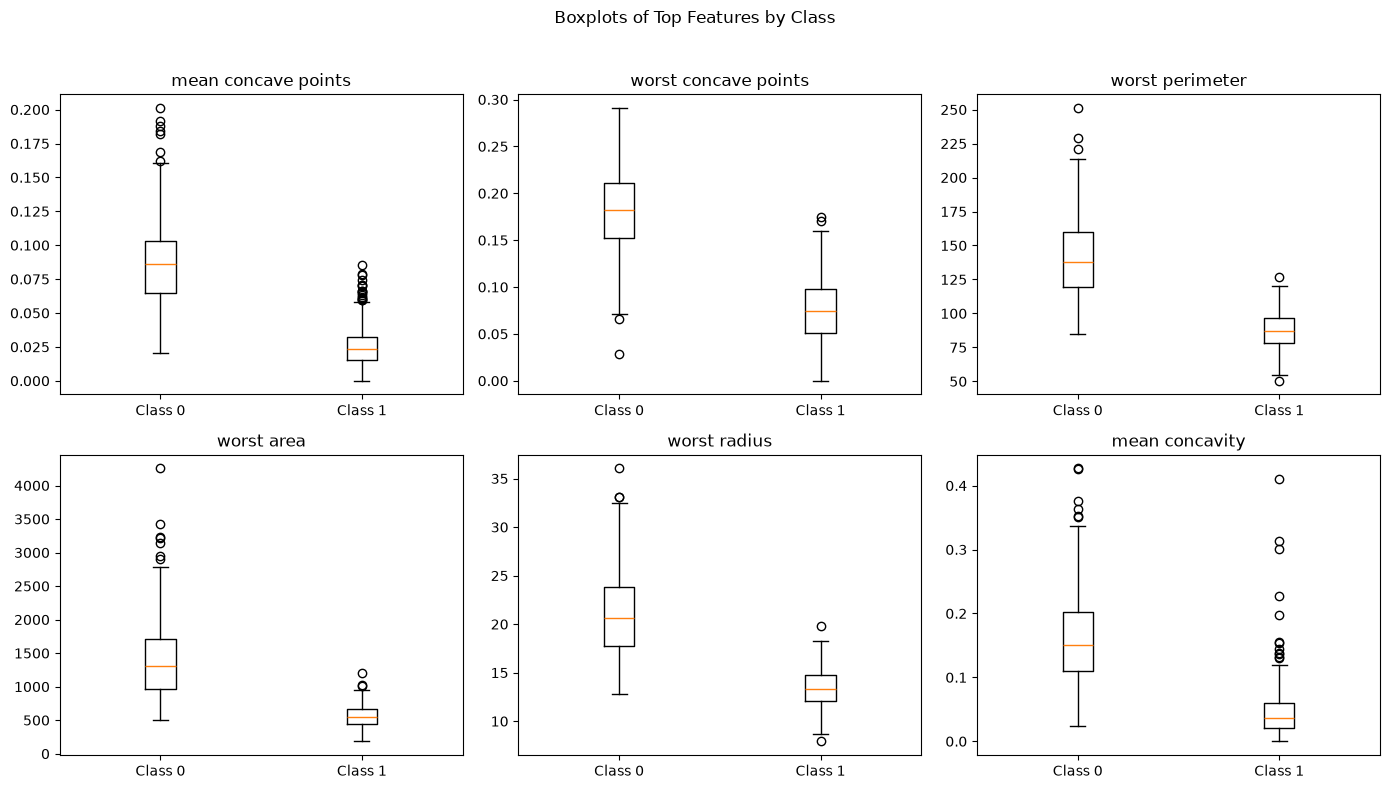

<Figure size 640x480 with 0 Axes>

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# choose feature importances from model_full if available, else from model_sel
if 'model_full' in globals():
    imp = model_full.feature_importances_
    names = np.asarray(X.columns) if hasattr(X, "columns") else np.arange(len(imp))
    top6_idx = np.argsort(imp)[-6:][::-1]
    top6_names = names[top6_idx]
else:
    # fallback: use selected_features as candidates
    top6_idx = selected_features[:6] if len(selected_features) >= 1 else np.arange(min(6, X.shape[1]))
    top6_names = np.asarray(X.columns)[top6_idx] if hasattr(X, "columns") else top6_idx

# For each top feature, show boxplot split by class
y_np = np.asarray(y)
fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.ravel()
for ax, feat in zip(axes, top6_names):
    col = feat if isinstance(feat, str) else int(feat)  # handle name or index
    # original X might be DataFrame or ndarray
    if hasattr(X, "loc"):
        vals0 = X.loc[y_np == 0, col]
        vals1 = X.loc[y_np == 1, col]
    else:
        col_idx = int(col)
        X_np = np.asarray(X)
        vals0 = X_np[y_np == 0, col_idx]
        vals1 = X_np[y_np == 1, col_idx]
    ax.boxplot([vals0, vals1], positions=[0,1])
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Class 0','Class 1'])
    ax.set_title(str(col))
plt.suptitle("Boxplots of Top Features by Class")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
plt.savefig("top_features_boxplots.png", dpi=300, bbox_inches='tight')